# HESE Data Stability: Time Distribution of Events
Checks for periods with anomalously high event rates across all HESE datasets.

In [34]:
import os
import numpy as np
import pandas as pd
import tables
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Configuration

In [35]:
# Toggle 60 TeV reco_energy threshold (applies to all datasets)
APPLY_60TEV_THRESHOLD = False
ENERGY_THRESHOLD_GEV  = 60e3  # 60 TeV in GeV
ENERGY_SUFFIX         = '_60TeV' if APPLY_60TEV_THRESHOLD else '_noThreshold'

# Histogram binning
N_BINS = 50

# Output directory for saved figures
SAVE_PATH = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/"
    "step1_hese_flux/data_stability"
)
os.makedirs(SAVE_PATH, exist_ok=True)

## Helper functions

In [36]:
def mjd_to_datetime(mjd_arr):
    """Convert MJD array to numpy datetime64 for matplotlib date axes."""
    return Time(mjd_arr, format='mjd').to_datetime()


def apply_threshold(df, energy_col='reco_energy'):
    """Apply 60 TeV energy cut if enabled."""
    if APPLY_60TEV_THRESHOLD and energy_col in df.columns:
        return df[df[energy_col] >= ENERGY_THRESHOLD_GEV]
    return df


def load_parquet(path, label=None):
    """Load a parquet file and apply optional energy cut."""
    df = pd.read_parquet(path)
    # Flatten multi-index if present
    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index(drop=True)
    df = apply_threshold(df)
    if label:
        print(f"{label}: {len(df)} events")
    return df


def load_hese12_hdf(path, table_name):
    """
    Load a HESE12 HDF file (pytables format) and return a DataFrame
    with at least 'mjd' and 'reco_energy' columns.

    The column layout in values_block_1 is (from file attributes):
      [econfinement, eratio, mjd, reco_azimuth, reco_dir,
       reco_energy, reco_lbye, reco_length]
    """
    FLOAT_COLS = ['econfinement', 'eratio', 'mjd', 'reco_azimuth', 'reco_dir',
                  'reco_energy', 'reco_lbye', 'reco_length']
    with tables.open_file(path) as f:
        tbl = f.root[table_name]['table']
        rows = tbl[:]

    float_block = rows['values_block_1']  # shape (N, 8)
    df = pd.DataFrame(float_block, columns=FLOAT_COLS)
    df['event_id'] = rows['values_block_2'].squeeze()
    df = apply_threshold(df)
    return df


def plot_time_hist(ax, mjd, label, color, n_bins=N_BINS):
    """Plot a time histogram on ax, with the x-axis as calendar dates."""
    dates = mjd_to_datetime(mjd)
    ax.hist(dates, bins=n_bins, color=color, alpha=0.8, label=f"{label} (N={len(mjd)})")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('Year')
    ax.set_ylabel('Events / bin')
    ax.legend()
    threshold_str = f' [E > 60 TeV]' if APPLY_60TEV_THRESHOLD else ''
    ax.set_title(f"{label}{threshold_str}")

---
## 1. Combined dataset (with BDT)
`combined_with_bdt/data_HESE_pass2_v3/mcd-simpletopology_.../dataset_data_HESE_pass2_v3.parquet`

Combined (all topologies): 188 events


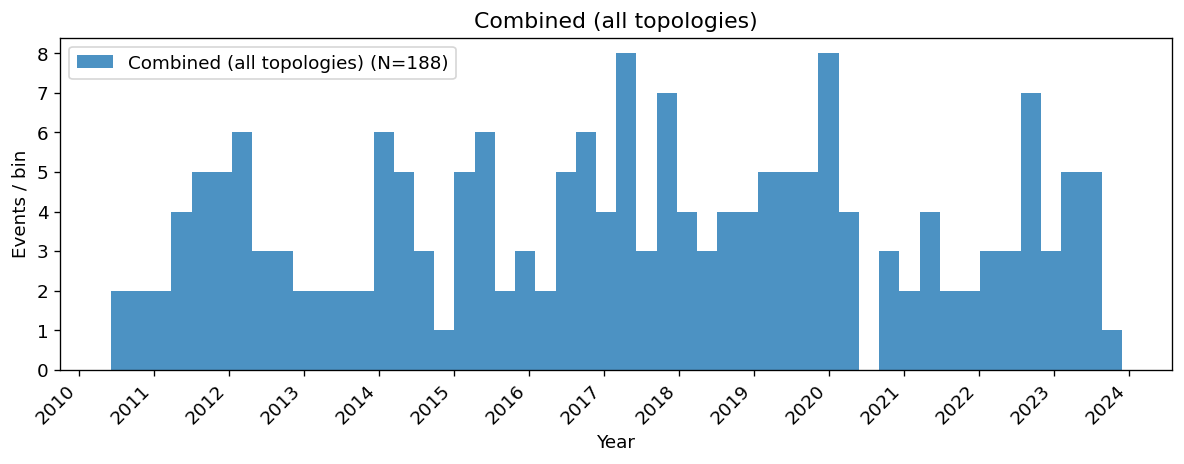

In [37]:
COMBINED_PATH = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined_with_bdt/data_HESE_pass2_v3/"
    "mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/"
    "dataset_data_HESE_pass2_v3.parquet"
)

df_combined = load_parquet(COMBINED_PATH, label='Combined (all topologies)')

fig, ax = plt.subplots(figsize=(10, 4))
plot_time_hist(ax, df_combined['mjd'].values, 'Combined (all topologies)', '#1f77b4')
fig.tight_layout()
fig.savefig(os.path.join(SAVE_PATH, f'combined{ENERGY_SUFFIX}.pdf'), bbox_inches='tight')
plt.show()

---
## 2. Split datasets — FinalTopology
`split/data_HESE_pass2_v3_FinalTopology/`

FT track: 51 events
FT cascade: 134 events
FT double: 3 events


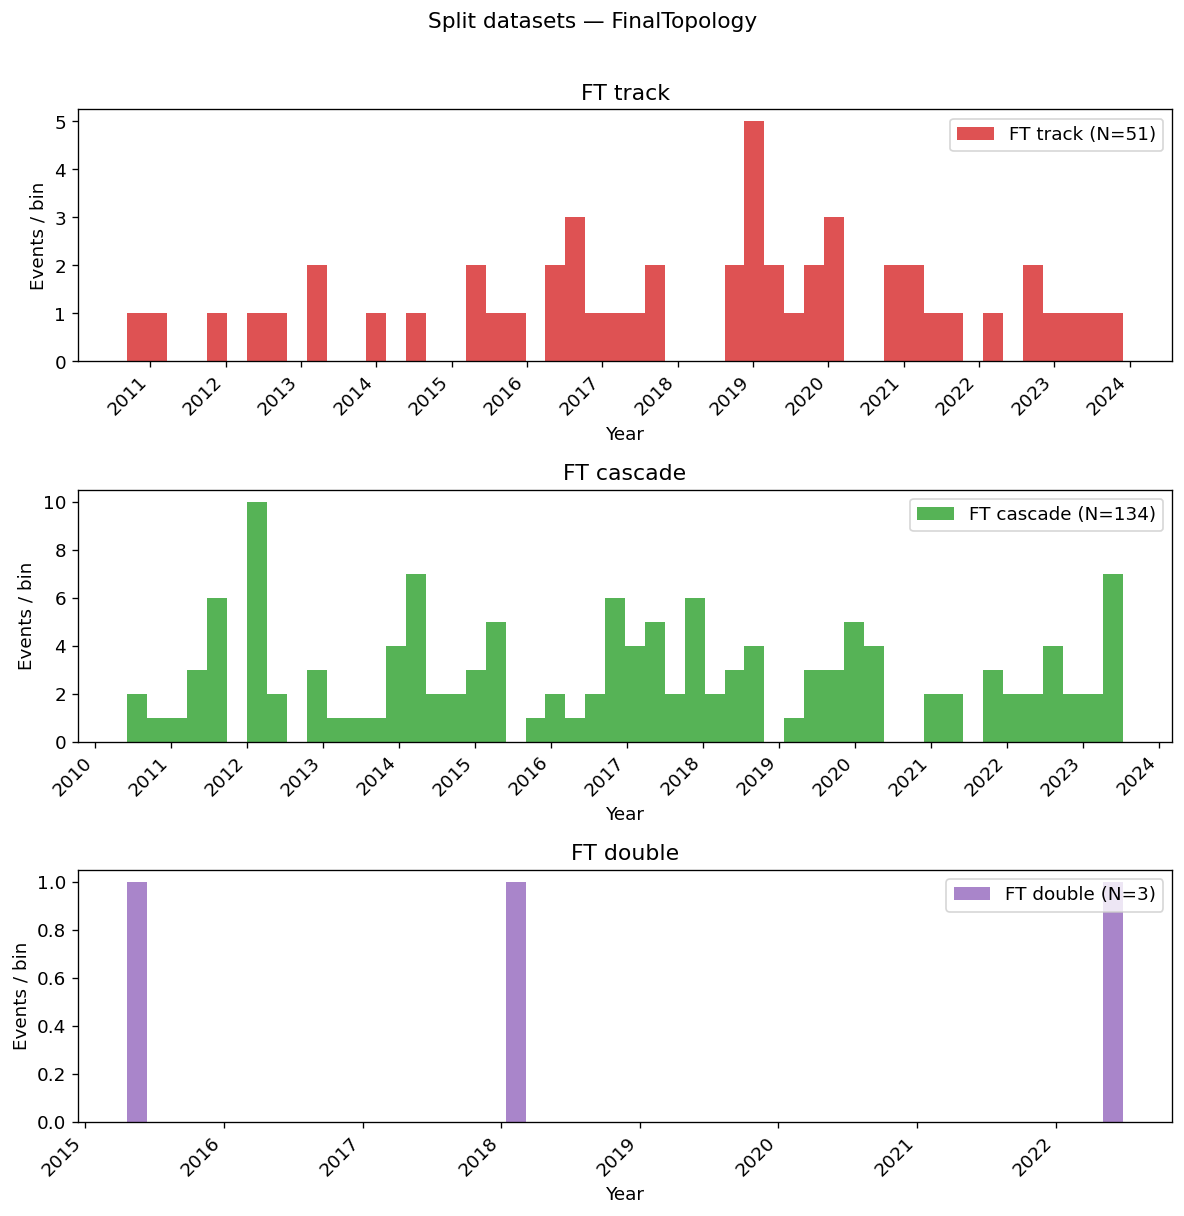

In [38]:
SPLIT_FT_DIR = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/split/data_HESE_pass2_v3_FinalTopology/"
)

df_ft_track   = load_parquet(SPLIT_FT_DIR + 'dataset_data_HESE_pass2_v3_track.parquet',   label='FT track')
df_ft_cascade = load_parquet(SPLIT_FT_DIR + 'dataset_data_HESE_pass2_v3_cascade.parquet', label='FT cascade')
df_ft_double  = load_parquet(SPLIT_FT_DIR + 'dataset_data_HESE_pass2_v3_double.parquet',  label='FT double')

colors_ft = ['#d62728', '#2ca02c', '#9467bd']
datasets_ft = [
    (df_ft_track,   'FT track',   colors_ft[0]),
    (df_ft_cascade, 'FT cascade', colors_ft[1]),
    (df_ft_double,  'FT double',  colors_ft[2]),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
for ax, (df, label, color) in zip(axes, datasets_ft):
    plot_time_hist(ax, df['mjd'].values, label, color)
fig.suptitle('Split datasets — FinalTopology', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_PATH, f'split_finaltopology{ENERGY_SUFFIX}.pdf'), bbox_inches='tight')
plt.show()

---
## 3. Split datasets — BDT cuts
`split/data_HESE_pass2_v3/mcd-simpletopology_.../bdt1_0.333333_bdt2_0.366667_length_10/`

BDT track: 64 events
BDT cascade: 122 events
BDT double: 2 events


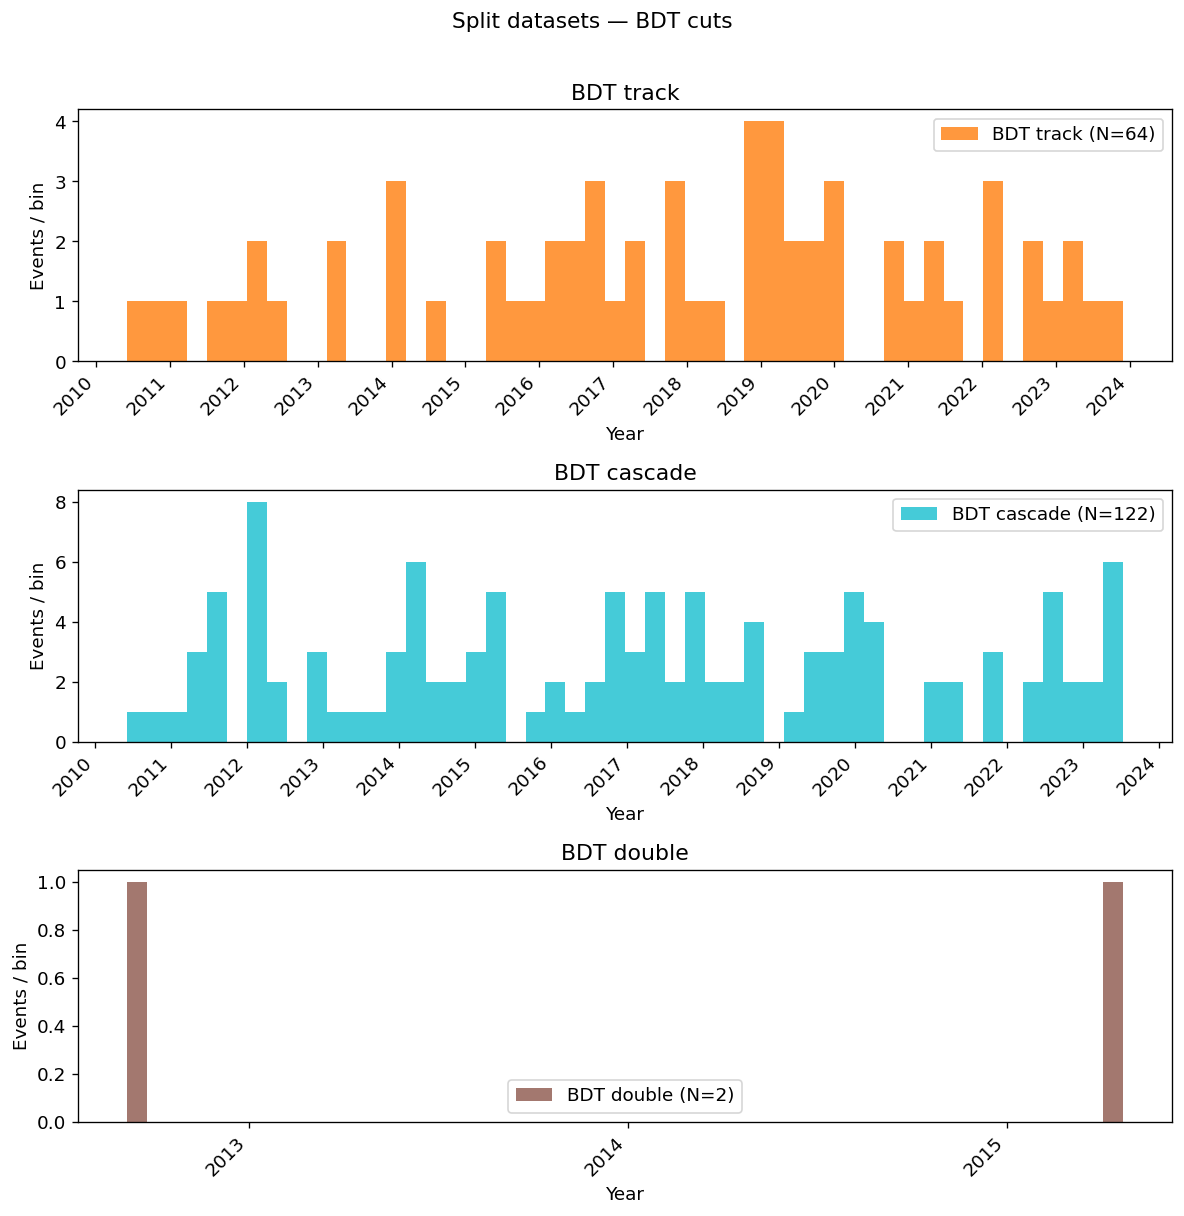

In [39]:
SPLIT_BDT_DIR = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/split/data_HESE_pass2_v3/"
    "mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/"
    "bdt1_0.333333_bdt2_0.366667_length_10/"
)

df_bdt_track   = load_parquet(SPLIT_BDT_DIR + 'dataset_data_HESE_pass2_v3_track.parquet',   label='BDT track')
df_bdt_cascade = load_parquet(SPLIT_BDT_DIR + 'dataset_data_HESE_pass2_v3_cascade.parquet', label='BDT cascade')
df_bdt_double  = load_parquet(SPLIT_BDT_DIR + 'dataset_data_HESE_pass2_v3_double.parquet',  label='BDT double')

colors_bdt = ['#ff7f0e', '#17becf', '#8c564b']
datasets_bdt = [
    (df_bdt_track,   'BDT track',   colors_bdt[0]),
    (df_bdt_cascade, 'BDT cascade', colors_bdt[1]),
    (df_bdt_double,  'BDT double',  colors_bdt[2]),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
for ax, (df, label, color) in zip(axes, datasets_bdt):
    plot_time_hist(ax, df['mjd'].values, label, color)
fig.suptitle('Split datasets — BDT cuts', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_PATH, f'split_bdt{ENERGY_SUFFIX}.pdf'), bbox_inches='tight')
plt.show()

---
## 4. HESE12 — WithoutDeepCore
`/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Datasets/data/HESE12/WithoutDeepCore/`

HESE12 Cascades: 64 events
HESE12 Tracks: 28 events
HESE12 DoubleCascades: 5 events


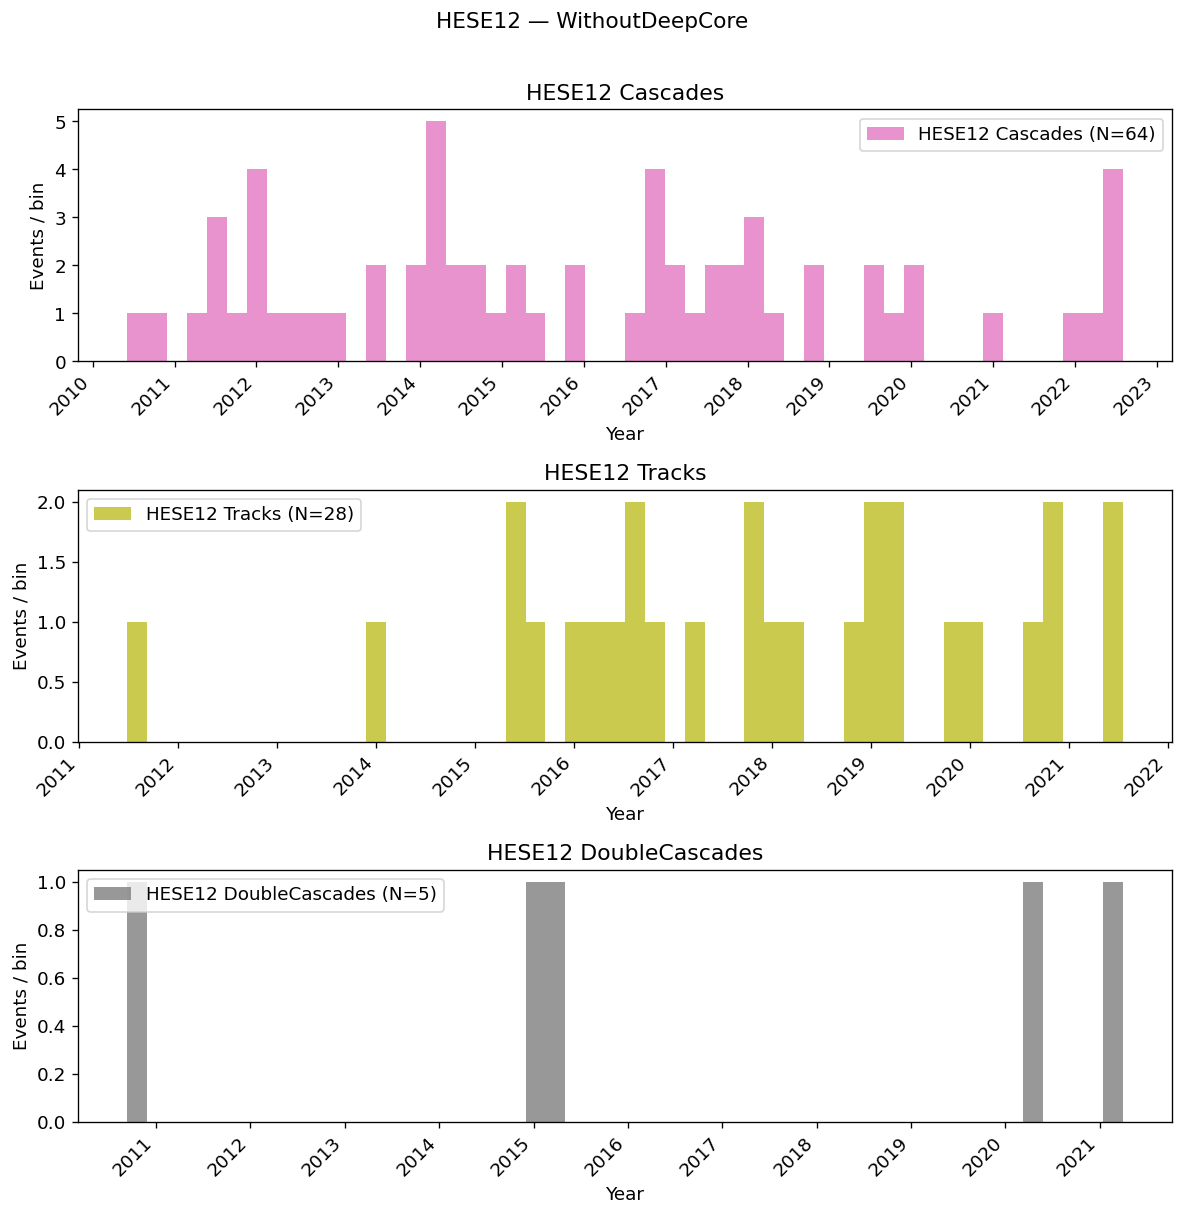

In [40]:
HESE12_BASE = "/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Datasets/data/HESE12/WithoutDeepCore/"

hese12_files = {
    'HESE12 Cascades':       (HESE12_BASE + 'data_HESE12_Cascades/dataset_HESE12_Cascades.hdf',
                               'dataset_HESE12_Cascades'),
    'HESE12 Tracks':         (HESE12_BASE + 'data_HESE12_Tracks/dataset_HESE12_Tracks.hdf',
                               'dataset_HESE12_Tracks'),
    'HESE12 DoubleCascades': (HESE12_BASE + 'data_HESE12_DoubleCascades/dataset_HESE12_DoubleCascades.hdf',
                               'dataset_HESE12_DoubleCascades'),
}

colors_h12 = ['#e377c2', '#bcbd22', '#7f7f7f']

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
for ax, ((label, (path, tbl_name)), color) in zip(axes, zip(hese12_files.items(), colors_h12)):
    df = load_hese12_hdf(path, tbl_name)
    print(f"{label}: {len(df)} events")
    plot_time_hist(ax, df['mjd'].values, label, color)

fig.suptitle('HESE12 — WithoutDeepCore', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_PATH, f'hese12_withoutdeepcore{ENERGY_SUFFIX}.pdf'), bbox_inches='tight')
plt.show()

---
## 5. Overview: all datasets on one figure

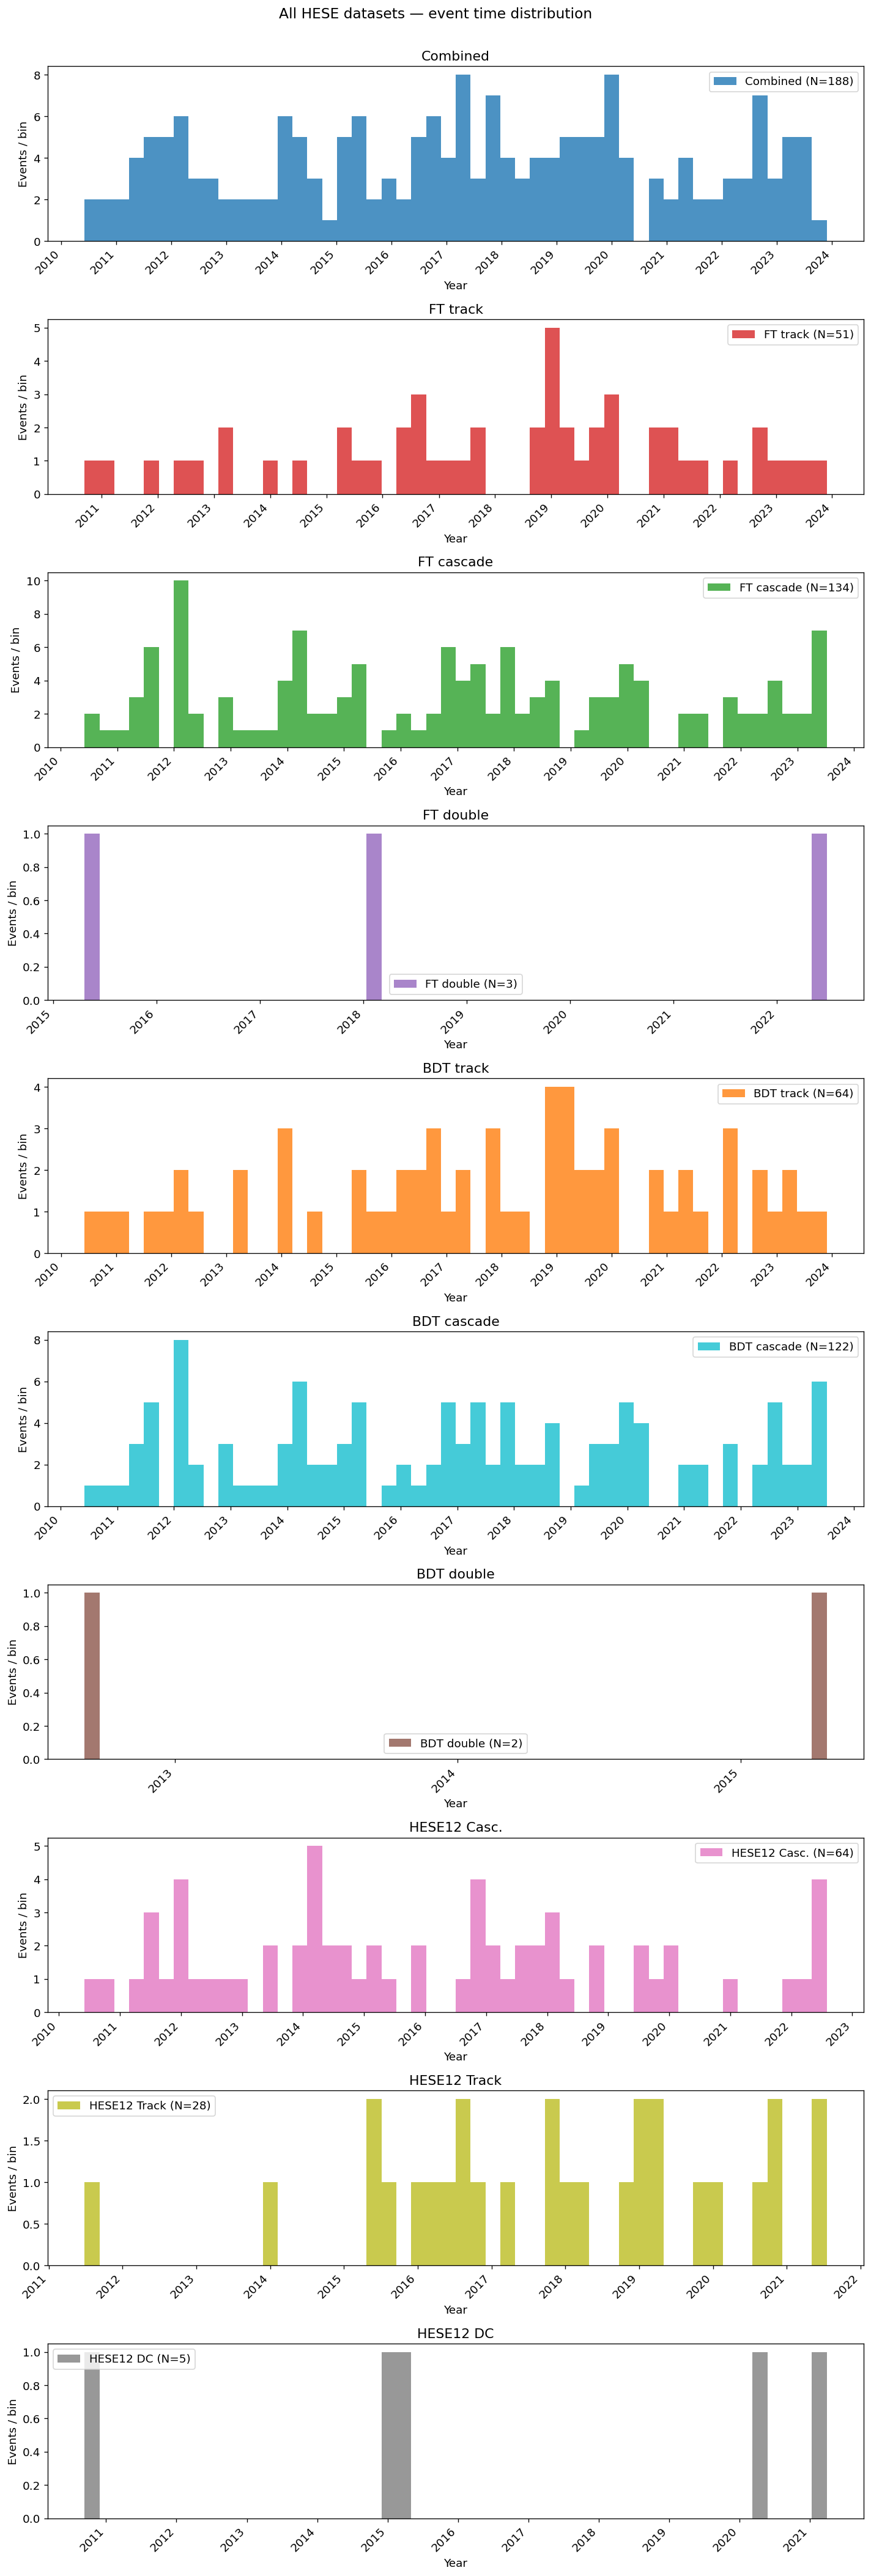

In [41]:
# Reload HESE12 frames for the overview
df_h12_cascades = load_hese12_hdf(
    HESE12_BASE + 'data_HESE12_Cascades/dataset_HESE12_Cascades.hdf', 'dataset_HESE12_Cascades')
df_h12_tracks   = load_hese12_hdf(
    HESE12_BASE + 'data_HESE12_Tracks/dataset_HESE12_Tracks.hdf', 'dataset_HESE12_Tracks')
df_h12_doubles  = load_hese12_hdf(
    HESE12_BASE + 'data_HESE12_DoubleCascades/dataset_HESE12_DoubleCascades.hdf', 'dataset_HESE12_DoubleCascades')

all_datasets = [
    (df_combined,   'Combined',           '#1f77b4'),
    (df_ft_track,   'FT track',           '#d62728'),
    (df_ft_cascade, 'FT cascade',         '#2ca02c'),
    (df_ft_double,  'FT double',          '#9467bd'),
    (df_bdt_track,  'BDT track',          '#ff7f0e'),
    (df_bdt_cascade,'BDT cascade',        '#17becf'),
    (df_bdt_double, 'BDT double',         '#8c564b'),
    (df_h12_cascades,    'HESE12 Casc.',  '#e377c2'),
    (df_h12_tracks,      'HESE12 Track',  '#bcbd22'),
    (df_h12_doubles,     'HESE12 DC',     '#7f7f7f'),
]

n = len(all_datasets)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=False)

for ax, (df, label, color) in zip(axes, all_datasets):
    plot_time_hist(ax, df['mjd'].values, label, color)

threshold_str = ' [E > 60 TeV]' if APPLY_60TEV_THRESHOLD else ''
fig.suptitle(f'All HESE datasets — event time distribution{threshold_str}', fontsize=14, y=1.002)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_PATH, f'overview_all_datasets{ENERGY_SUFFIX}.pdf'), bbox_inches='tight')
plt.show()